| Name                        | Questions        | Contribution                                                                 |
|-----------------------------|------------------|------------------------------------------------------------------------------|
| Jisna D Kunju               | Question 2 | Own Solution   |
| Jissy Jayaprakash           | Question 4 | Own Solution   |
| Anjitha Mohan               | Question 2 | Own Solution   |
| Aman Nain                   | Question 5 | Own Solution   |
| Prakash Phakami Pun         | Question 5 | Own Solution   |
| Bibek Ranjit                | Question 4 | Own Solution   |
| Leandro Sartini de Campos   | Question 1 | Own Solution   |
| Jorge Rodrigo Velazquez     | Question 3 | Own Solution   |


In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import shutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom,Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
import cv2

## Question 3

<b> Prompts used were mostly based on GPT help me fix this bug (Mostly related to shapes) or remembering details of augmentation layer.

| Sub-task	| Comments |
|-----------|----------|
| Scaling and Resizing |	Done |
| Image Augmentation |	Done |
| Train and test data handled correctly |	Done |
| Gaussian Blur, Histogram Equalization and Intensity thresholds |	Done |
| Training Time? |	Done |
| AUC and Confusion Matrix Computed |	Done |
| Overfitting/Underfitting checked and handled |	Done |
| Interpretability Implemented |	Even when the model got it right was based purely on randomness because for food it was paying attetion to the person itself  |
| 1st Round of Tuning |	Model runs faster but still overfits a lot, removed some complexity |
| 2nd Round of Tuning |	Used only last layer and tried to increase the dropout, also saw that model was pending to only classes and removed them from augmentation |


In [2]:
# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevent full memory allocation
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU is now being used for TensorFlow!")
    except RuntimeError as e:
        print(e)


✅ GPU is now being used for TensorFlow!


In [3]:
#import pandas as pd
#
#def filter_valid_images(photo_ids, img_dir):
#    """Check for missing/corrupt images and return a cleaned DataFrame."""
#    valid_photo_ids = []
#    invalid_photo_ids = []
#
#    for photo_id in photo_ids:
#        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
#        if os.path.exists(img_path):
#            try:
#                img = tf.io.read_file(img_path)
#                img = tf.image.decode_jpeg(img, channels=3)  # Try decoding to detect corruption
#                valid_photo_ids.append(photo_id)
#            except tf.errors.InvalidArgumentError:
#                invalid_photo_ids.append(photo_id)
#
#    print(f"✅ {len(valid_photo_ids)} valid images, ❌ {len(invalid_photo_ids)} corrupt images removed.")
#    return valid_photo_ids
#
## Filter the dataset and update the DataFrame
#valid_photo_ids = filter_valid_images(photos_df["photo_id"], "data/photos")
#cleaned_photos_df = photos_df[photos_df["photo_id"].isin(valid_photo_ids)].reset_index(drop=True)
#
## Save cleaned DataFrame
#cleaned_photos_df.to_csv("cleaned_photos.csv", index=False)

cleaned_photos_df = pd.read_csv("cleaned_photos.csv")


In [4]:
def apply_gaussian_blur(image_np):
    """Apply Gaussian Blur to an image."""
    return cv2.GaussianBlur(image_np, (5, 5), 0)

def apply_histogram_equalization(image_np):
    """Apply histogram equalization ensuring uint8 type."""
    if image_np.dtype != np.uint8:
        image_np = (image_np * 255).astype(np.uint8)  # Convert from float32 to uint8
    return cv2.equalizeHist(image_np)


def apply_intensity_thresholding(image_np):
    """Apply intensity thresholding to an image."""
    _, image_np = cv2.threshold(image_np, 127, 255, cv2.THRESH_BINARY)
    return image_np

def apply_augmentation(image):
    """Apply data augmentation techniques."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image

def preprocess_image(image):
    """Convert image to grayscale, apply preprocessing and augmentation using tf.py_function()."""
    
    def _preprocess_np(image_tensor):
        """Helper function for NumPy-based preprocessing."""
        import cv2  # Ensure cv2 is available
        
        # Convert TensorFlow tensor to a NumPy array
        image_np = image_tensor.numpy()

        # Ensure image is a valid NumPy array
        if not isinstance(image_np, np.ndarray):
            image_np = np.array(image_np)

        # Convert to grayscale
        image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
        image_np = apply_gaussian_blur(image_np)
        image_np = apply_histogram_equalization(image_np)
        image_np = apply_intensity_thresholding(image_np)
        image_np = cv2.cvtColor(image_np, cv2.COLOR_GRAY2RGB)  # Convert back to RGB

        return image_np.astype(np.float32) / 255.0  # Normalize

    # Convert Tensor to NumPy using tf.py_function
    image = tf.py_function(func=_preprocess_np, inp=[image], Tout=tf.float32)

    # Ensure correct shape
    image.set_shape((128, 128, 3))

    # Apply augmentation
    image = apply_augmentation(image)

    return image


def load_image(image_path, IMAGE_SIZE):
    """Load and decode an image."""
    img = tf.io.read_file(image_path)
    return tf.image.decode_jpeg(img, channels=3)

def resize_image(image, IMAGE_SIZE):
    """Resize image to specified dimensions."""
    return tf.image.resize(image, IMAGE_SIZE)

def load_image_label(image_path, label, IMAGE_SIZE=(128, 128)):
    """Load, preprocess, and resize a single image while handling corrupt images."""
    try:
        img = load_image(image_path, IMAGE_SIZE)
        img = resize_image(img, IMAGE_SIZE)
        img = preprocess_image(img)
        return img, label
    except tf.errors.InvalidArgumentError:
        print(f"Skipping corrupt image: {image_path}")
        return tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label

def load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(128, 128), batch_size=128):
    """Load images and labels using tf.data, handling corrupt images."""
    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(lambda x, y: load_image_label(x, y, IMAGE_SIZE), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Load test dataset without augmentation
def load_images_without_augmentation(photo_ids, labels, img_dir, IMAGE_SIZE=(128, 128), batch_size=128):
    """Load test images without augmentation."""
    def load_image_label(image_path, label):
        try:
            img = tf.io.read_file(image_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, IMAGE_SIZE)
            img = tf.convert_to_tensor(img, dtype=tf.float32) / 255.0  # Normalize
            return img, label
        except tf.errors.InvalidArgumentError:
            print(f"Skipping corrupt image: {image_path}")
            return tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label

    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Compute class weights
def get_class_weights(labels):
    """Compute class weights to handle imbalanced classes."""
    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
    return {i: weight for i, weight in enumerate(class_weights)}

### The exercise asks us to: 

- Scaling and Resizing -> load_image_label
- Image Augmentation -> apply_augmentation
- Train and test data handled correctly -> get_class_weights for loss adjustments and splitting into train and test
- Gaussian Blur, Histogram Equalization and Intensity thresholds -> apply_gaussian_blur,apply_intensity_thresholding,apply_histogram_equalization
- Training Time? Measured in training
- AUC and Confusion Matrix Computed -> Implemented
- Overfitting/Underfitting checked and handled -> Done after first run
- Interpretability -> Implemented
- 2nd Round of Tuning -> Done


First we will transform the labels so that the images can be converted.

In [9]:
# Convert labels to integers
label_encoder = LabelEncoder()
cleaned_photos_df["label"] = label_encoder.fit_transform(cleaned_photos_df["label"])

# Save the mapping (optional, useful for later decoding)
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

Label Mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [10]:
## Saving the class weights to be used later
class_weights = get_class_weights(cleaned_photos_df["label"].values)

In [11]:
# Train-test split with stratification
train_df, test_df = train_test_split(cleaned_photos_df, test_size=0.2, stratify=cleaned_photos_df["label"], random_state=42)

In [12]:
# Load images into TensorFlow datasets
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 128
IMG_DIR = "data/photos"

# Load train dataset with augmentation
train_dataset = load_images_with_tf(train_df["photo_id"].values, train_df["label"].values, IMG_DIR, IMAGE_SIZE, BATCH_SIZE)
test_dataset = load_images_without_augmentation(test_df["photo_id"].values, test_df["label"].values, IMG_DIR, IMAGE_SIZE, BATCH_SIZE)

In [13]:
train_dataset

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [16]:
def load_b0_and_create_model():
    # Load EfficientNetB0 with custom input size
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = True  # Enable fine-tuning

    # Unfreeze the last 3 layers
    for layer in base_model.layers[-2:]:
        layer.trainable = True

    # Add global average pooling and a classification layer
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(5, activation="softmax")  # Adjust for number of classes
    ])

    return model

In [17]:
model = load_b0_and_create_model()

In [18]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [19]:
import time

# Start timing
start_time = time.time()
model.fit(train_dataset, epochs=3, validation_data=test_dataset, class_weight=class_weights)
# End timing
end_time = time.time()

# Print total training time
total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/3
1250/1250 [==============================] - 436s 338ms/step - loss: 1.5109 - accuracy: 0.3075 - val_loss: 2.2974 - val_accuracy: 0.0747
Epoch 2/3
1250/1250 [==============================] - 496s 397ms/step - loss: 1.4243 - accuracy: 0.3900 - val_loss: 1.8526 - val_accuracy: 0.0827
Epoch 3/3
1250/1250 [==============================] - 496s 396ms/step - loss: 1.3897 - accuracy: 0.4120 - val_loss: 2.0489 - val_accuracy: 0.0084
Total training time: 1440.01 seconds


- Epoch 1/3
- 1250/1250 [==============================] - 436s 338ms/step - loss: 1.5109 - accuracy: 0.3075 - val_loss: 2.2974 - val_accuracy: 0.0747
- Epoch 2/3
- 1250/1250 [==============================] - 496s 397ms/step - loss: 1.4243 - accuracy: 0.3900 - val_loss: 1.8526 - val_accuracy: 0.0827
- Epoch 3/3
- 1250/1250 [==============================] - 496s 396ms/step - loss: 1.3897 - accuracy: 0.4120 - val_loss: 2.0489 - val_accuracy: 0.0084
- Total training time: 1440.01 seconds

In [22]:
model.save_weights("efficientnetb0_weights.h5")

# Train

In [26]:
# Get model predictions
y_pred_prob = model.predict(train_dataset)  # Predicted probabilities
y_true = train_df["label"].values  # True labels

# Compute AUC
overall_auc = roc_auc_score(y_true, y_pred_prob, multi_class="ovr")
print(f"Overall AUC: {overall_auc:.4f}")

1250/1250 [==============================] - 330s 264ms/step
Overall AUC: 0.5383


In [27]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
num_classes = len(label_encoder.classes_)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute AUC per class
auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
for i, class_label in enumerate(label_encoder.classes_):
    print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

AUC for 0: 0.5316
AUC for 1: 0.5160
AUC for 2: 0.5544
AUC for 3: 0.5674
AUC for 4: 0.5219


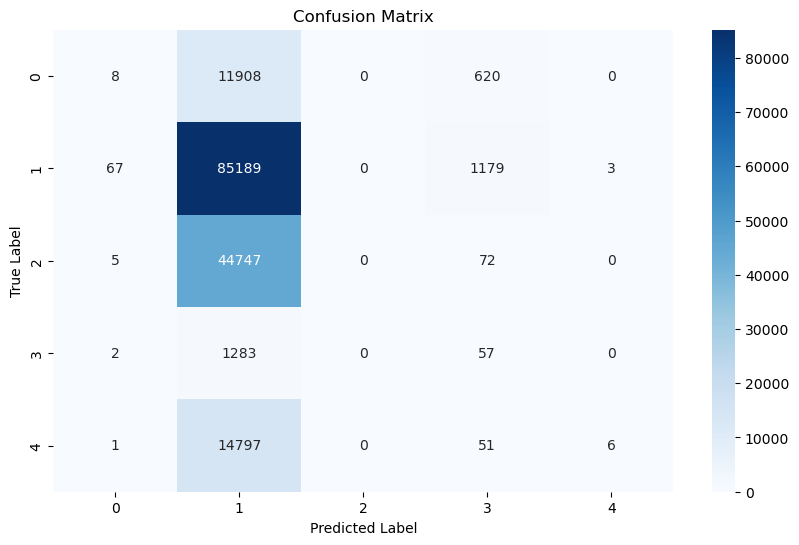

In [28]:
# Convert predictions to class labels
y_pred_classes = y_pred_prob.argmax(axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Test

In [30]:
# Get model predictions
y_pred_prob = model.predict(test_dataset)  # Predicted probabilities
y_true = test_df["label"].values  # True labels

# Compute AUC
overall_auc = roc_auc_score(y_true, y_pred_prob, multi_class="ovr")
print(f"Overall AUC: {overall_auc:.4f}")

313/313 [==============================] - 13s 40ms/step
Overall AUC: 0.4956


In [31]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
num_classes = len(label_encoder.classes_)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute AUC per class
auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
for i, class_label in enumerate(label_encoder.classes_):
    print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

AUC for 0: 0.4188
AUC for 1: 0.4431
AUC for 2: 0.5243
AUC for 3: 0.6044
AUC for 4: 0.4875


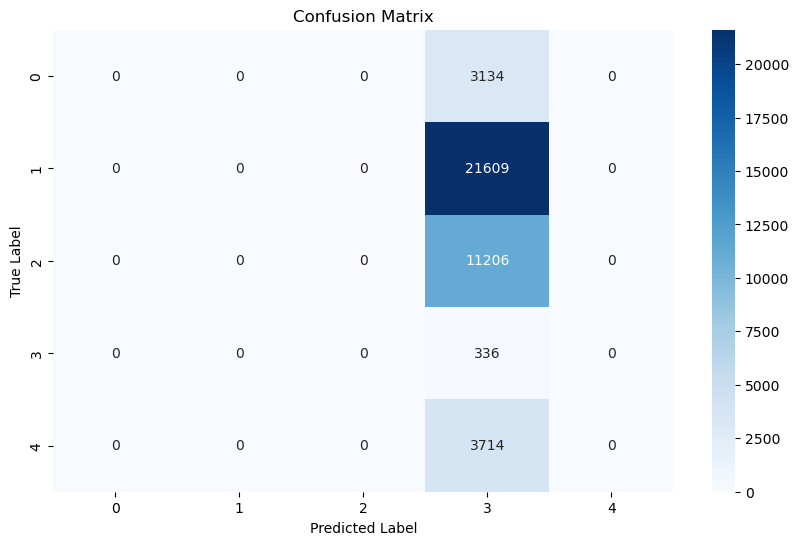

In [32]:
# Convert predictions to class labels
y_pred_classes = y_pred_prob.argmax(axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ROC AUC Curve

In [33]:
from sklearn.preprocessing import label_binarize

# Get model predictions (probabilities)
y_train_prob = model.predict(train_dataset)
y_val_prob = model.predict(test_dataset)

# Convert true labels to NumPy arrays
y_train_true = train_df["label"].values
y_val_true = test_df["label"].values

# Convert labels to one-hot encoding for ROC curve
num_classes = len(label_encoder.classes_)
y_train_bin = label_binarize(y_train_true, classes=list(range(num_classes)))
y_val_bin = label_binarize(y_val_true, classes=list(range(num_classes)))

313/313 [==============================] - 12s 38ms/step


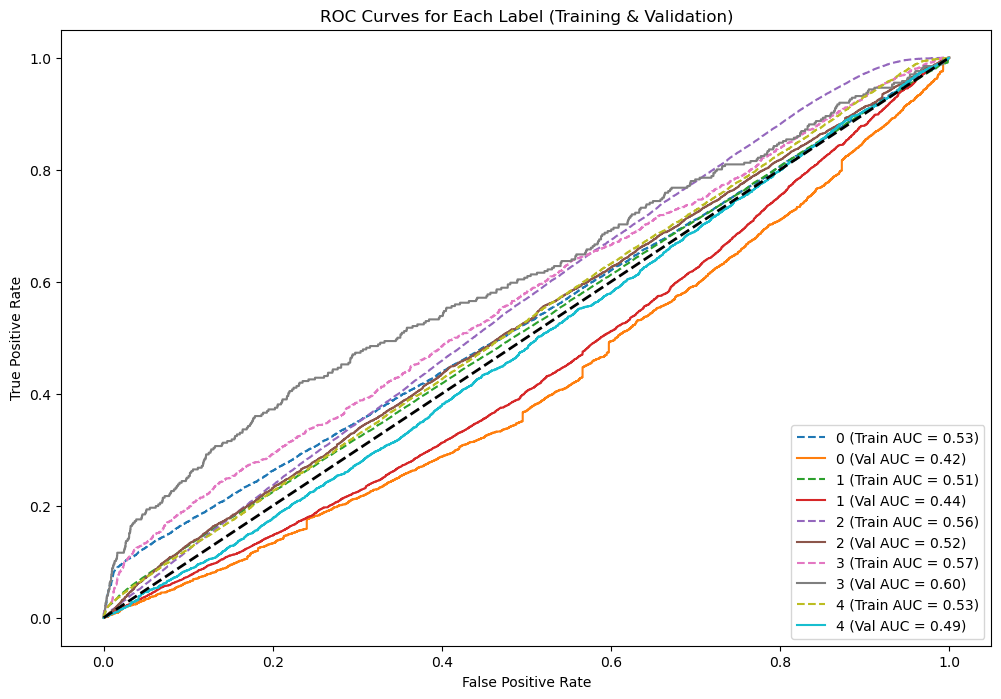

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Set up the figure
plt.figure(figsize=(12, 8))

for i, class_label in enumerate(label_encoder.classes_):
    # Compute ROC curve for training set
    fpr_train, tpr_train, _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc_train = auc(fpr_train, tpr_train)

    # Compute ROC curve for validation set
    fpr_val, tpr_val, _ = roc_curve(y_val_bin[:, i], y_val_prob[:, i])
    roc_auc_val = auc(fpr_val, tpr_val)

    # Plot both training and validation curves
    plt.plot(fpr_train, tpr_train, linestyle="--", label=f"{class_label} (Train AUC = {roc_auc_train:.2f})")
    plt.plot(fpr_val, tpr_val, label=f"{class_label} (Val AUC = {roc_auc_val:.2f})")

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], "k--", lw=2)

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Label (Training & Validation)")
plt.legend(loc="lower right")
plt.show()

In [36]:
for batch_images, batch_labels in test_dataset.take(1):
    test_image = batch_images[1].numpy()  # Extract an image
    test_label = batch_labels[1].numpy()  # Extract the corresponding label
    break 

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 34ms/step
Top labels explained: [3, 0, 1, 4, 2]


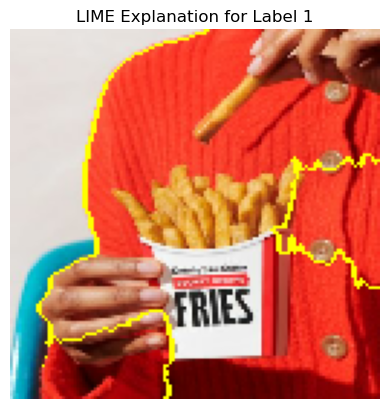

1/1 [==============================] - 0s 41ms/step
Predicted probabilities: [[0.18956225 0.1601948  0.07395057 0.47029138 0.10600095]]
True label probability: 0.16019479930400848


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Ensure the model input format is correct for LIME
def preprocess_image_for_lime(image):
    """Preprocess a single image for LIME (resize, normalize)."""
    image = tf.image.resize(image, (128, 128))  # Resize to match model input
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    return image.numpy()

# Define prediction function for LIME
def predict_proba_for_lime(images):
    """Predict probabilities for a batch of images using the trained DNN."""
    processed_images = np.array([preprocess_image_for_lime(img) for img in images])  # Apply preprocessing
    return model.predict(processed_images)  # Get predictions

# Extract a sample from val_dataset
for batch_images, batch_labels in test_dataset.take(1):
    test_image = batch_images[1].numpy()  # Extract an image
    test_label = batch_labels[1].numpy()  # Extract the corresponding label
    break  # Stop after first batch

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate explanation
explanation = explainer.explain_instance(
    test_image,  
    predict_proba_for_lime,  # Prediction function for LIME
    labels=[test_label],  # Focus on the true label
    hide_color=0,  
    num_samples=1000  # Number of perturbed samples
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Get LIME mask for the true label
temp, mask = explanation.get_image_and_mask(
    label=test_label,  
    positive_only=True,  
    num_features=10,  
    hide_rest=False  
)

# Convert to proper format if needed
if len(temp.shape) == 2:  
    temp = np.stack([temp] * 3, axis=-1)  # Convert grayscale to RGB

# Overlay mask on image
overlay = mark_boundaries(temp, mask)

# Display explanation
plt.imshow(overlay)
plt.title(f"LIME Explanation for Label {test_label}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = predict_proba_for_lime([test_image])
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, test_label]}")


In [39]:
class_names = label_encoder.classes_
print("Class names:", class_names)

Class names: [0 1 2 3 4]


### There's a few things.
- The model is just learning one class and not the others. We will try balancing the dataset.
- Maybe all those transformation steps are not so great, we must remember that imagenet is already trained on a lot of things. let's keep it simple and see how it goes
- We will also try to remove the balancing on class weights

## Change the load_image_label function to not use everything and increase augmentation

In [90]:
def apply_augmentation(image, IMAGE_SIZE=(128, 128)):  
    """Apply multiple data augmentation techniques and ensure all images have the same shape."""
    augmented_images = []
    
    # Original image (no augmentation)
    augmented_images.append(image)

    # Augmented versions
    augmented_images.append(tf.image.random_flip_left_right(image))
    augmented_images.append(tf.image.random_flip_up_down(image))
    augmented_images.append(tf.image.random_brightness(image, max_delta=0.3))
    augmented_images.append(tf.image.random_contrast(image, lower=0.7, upper=1.3))
    augmented_images.append(tf.image.rot90(image))  # Rotate 90 degrees

    # Central crop (fix shape mismatch)
    cropped_image = tf.image.central_crop(image, central_fraction=0.8)
    cropped_image = tf.image.resize(cropped_image, IMAGE_SIZE)  # Resize back to 128x128
    augmented_images.append(cropped_image)

    return tf.stack(augmented_images)  # Convert list to Tensor


In [91]:
def load_image_label(image_path, label, IMAGE_SIZE=(128, 128), augment=False):
    """Load, preprocess, and optionally apply augmentation to an image."""
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)  # Resize for EfficientNetB0
        img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]

        # Apply augmentation only for training data
        if augment:
            augmented_imgs = apply_augmentation(img)  # Returns multiple augmented versions
            labels = tf.repeat(label, augmented_imgs.shape[0])  # Repeat labels for each augmentation
            return tf.data.Dataset.from_tensor_slices((augmented_imgs, labels))  # Flatten dataset
        
        return tf.data.Dataset.from_tensors((img, label))  # Wrap single image in dataset
    except tf.errors.InvalidArgumentError:
        print(f"Skipping corrupt image: {image_path}")
        return tf.data.Dataset.from_tensors((tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label))


In [92]:
def load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(128, 128), batch_size=128, augment=False):
    """Load images and labels using tf.data, handling corrupt images and augmentation."""
    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    # Use `flat_map()` since `load_image_label()` now returns a Dataset
    dataset = dataset.flat_map(lambda x, y: load_image_label(x, y, IMAGE_SIZE, augment=augment))
    dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

    return dataset


First we will transform the labels so that the images can be converted.

In [93]:
cleaned_photos_df = pd.read_csv("cleaned_photos.csv")

In [48]:
# Convert labels to integers
label_encoder = LabelEncoder()
cleaned_photos_df["label"] = label_encoder.fit_transform(cleaned_photos_df["label"])

# Save the mapping (optional, useful for later decoding)
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [49]:
from sklearn.utils import resample

def undersample_data(df, label_column):
    """Undersamples dataset to match the minority class size."""
    min_class_size = df[label_column].value_counts().min()  # Find the smallest class size
    balanced_df = df.groupby(label_column, group_keys=False).apply(lambda x: x.sample(min_class_size, random_state=42))
    return balanced_df.sample(frac=1, random_state=42)  # Shuffle dataset

# Apply undersampling before splitting
balanced_df = undersample_data(cleaned_photos_df, "label")

# Now apply the train-test split
train_df, test_df = train_test_split(balanced_df, test_size=0.2, stratify=balanced_df["label"], random_state=42)

C:\Users\leand\AppData\Local\Temp\ipykernel_9100\1525273233.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby(label_column, group_keys=False).apply(lambda x: x.sample(min_class_size, random_state=42))


In [51]:
# Load images into TensorFlow datasets
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 128
IMG_DIR = "data/photos"

# Load train dataset with augmentation
train_dataset = load_images_with_tf(train_df["photo_id"].values, train_df["label"].values, IMG_DIR, IMAGE_SIZE, BATCH_SIZE,augment=True)
test_dataset = load_images_without_augmentation(test_df["photo_id"].values, test_df["label"].values, IMG_DIR, IMAGE_SIZE, BATCH_SIZE)

In [52]:
def load_b0_and_create_model():
    # Load EfficientNetB0 with custom input size
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = True  # Enable fine-tuning

    # Unfreeze the last 3 layers
    for layer in base_model.layers[-2:]:
        layer.trainable = True

    model = tf.keras.Sequential([
        base_model,  
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),  # Conv layer after base model
        layers.Dropout(0.5),  # Normalize activations
        layers.MaxPooling2D(pool_size=(2, 2)),  # Reduce spatial size
        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),  # Another Conv layer
        layers.Dropout(0.5),
        layers.MaxPooling2D(pool_size=(2, 2)),  # Pooling again
        
        layers.GlobalAveragePooling2D(),  # Convert to 1D before Dense layer
        layers.Dropout(0.5),  # Increased dropout to prevent overfitting
        layers.Dense(5, activation="softmax")  # Final classification layer
    ])

    return model

In [53]:
model = load_b0_and_create_model()

In [54]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [55]:
import time

# Start timing
start_time = time.time()
model.fit(train_dataset, epochs=3, validation_data=test_dataset)
# End timing
end_time = time.time()

# Print total training time
total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/3
367/367 [==============================] - 79s 176ms/step - loss: 0.4904 - accuracy: 0.8514 - val_loss: 1.6783 - val_accuracy: 0.2533
Epoch 2/3
367/367 [==============================] - 89s 226ms/step - loss: 0.2347 - accuracy: 0.9304 - val_loss: 1.8164 - val_accuracy: 0.2485
Epoch 3/3
367/367 [==============================] - 91s 226ms/step - loss: 0.1671 - accuracy: 0.9524 - val_loss: 1.8165 - val_accuracy: 0.2002
Total training time: 258.52 seconds


- Epoch 1/3
- 367/367 [==============================] - 79s 176ms/step - loss: 0.4904 - accuracy: 0.8514 - val_loss: 1.6783 - val_accuracy: 0.2533
- Epoch 2/3
- 367/367 [==============================] - 89s 226ms/step - loss: 0.2347 - accuracy: 0.9304 - val_loss: 1.8164 - val_accuracy: 0.2485
- Epoch 3/3
- 367/367 [==============================] - 91s 226ms/step - loss: 0.1671 - accuracy: 0.9524 - val_loss: 1.8165 - val_accuracy: 0.2002
- Total training time: 258.52 seconds

## Model is overfitting bigtime. Maybe I will try to unfreeze just the 1st and 2nd layer here and add batchnormalization + increase dropout

In [57]:
model.save_weights("efficientnetb0_tune1_weights.h5")

# Train

In [59]:
# Extract true labels from the dataset (instead of `train_df`)
y_true = np.concatenate([y.numpy() for _, y in train_dataset])

# Get model predictions
y_pred_prob = model.predict(train_dataset)

# Compute AUC
overall_auc = roc_auc_score(y_true, y_pred_prob, multi_class="ovr")
print(f"Overall AUC: {overall_auc:.4f}")

367/367 [==============================] - 31s 69ms/step
Overall AUC: 0.5016


In [60]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
num_classes = len(label_encoder.classes_)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute AUC per class
auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
for i, class_label in enumerate(label_encoder.classes_):
    print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

AUC for drink: 0.4988
AUC for food: 0.5066
AUC for inside: 0.5010
AUC for menu: 0.5041
AUC for outside: 0.4973


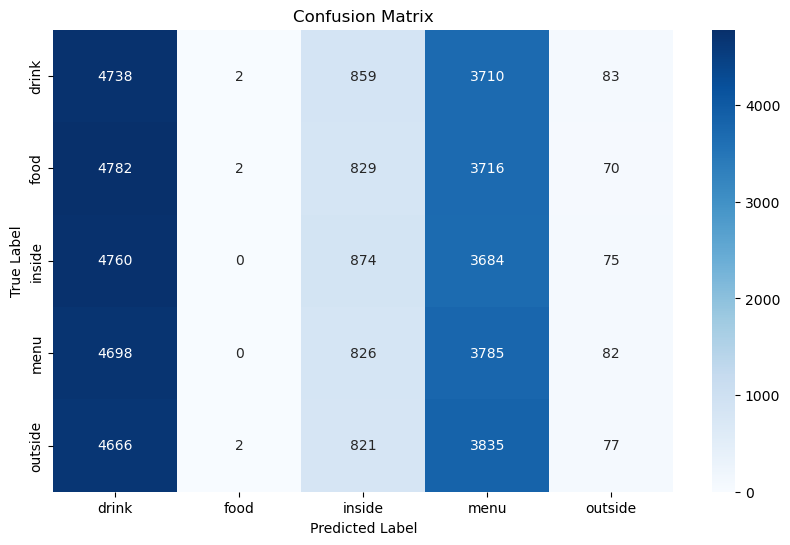

In [61]:
# Convert predictions to class labels
y_pred_classes = y_pred_prob.argmax(axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Weird, the model is learning very well drinks and menu, lets try augmenting only food, inside and outside.

# Test

In [62]:
# Get model predictions
y_pred_prob = model.predict(test_dataset)  # Predicted probabilities
y_true = test_df["label"].values  # True labels

# Compute AUC
overall_auc = roc_auc_score(y_true, y_pred_prob, multi_class="ovr")
print(f"Overall AUC: {overall_auc:.4f}")

14/14 [==============================] - 2s 71ms/step
Overall AUC: 0.5279


In [63]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
num_classes = len(label_encoder.classes_)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute AUC per class
auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
for i, class_label in enumerate(label_encoder.classes_):
    print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

AUC for drink: 0.4899
AUC for food: 0.4961
AUC for inside: 0.6444
AUC for menu: 0.4212
AUC for outside: 0.5880


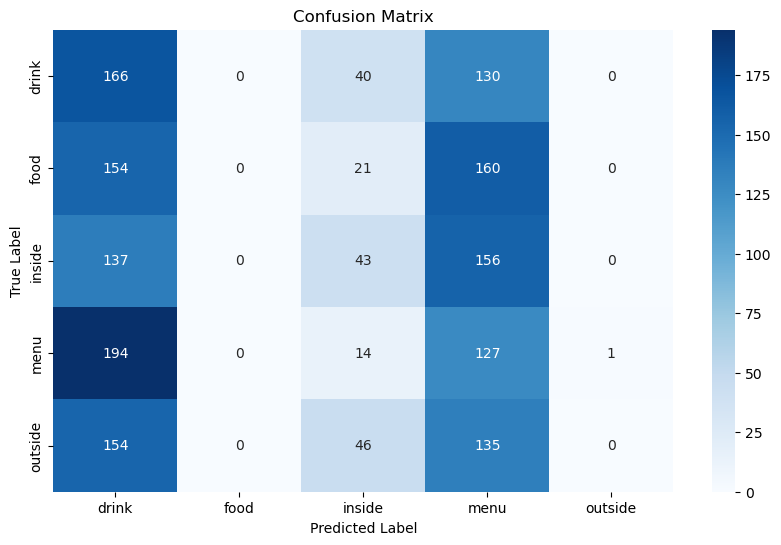

In [64]:
# Convert predictions to class labels
y_pred_classes = y_pred_prob.argmax(axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ROC AUC Curve

In [65]:
from sklearn.preprocessing import label_binarize

# Get model predictions (probabilities)
y_train_prob = model.predict(train_dataset)
y_val_prob = model.predict(test_dataset)

14/14 [==============================] - 1s 42ms/step


In [66]:
# Convert true labels to NumPy arrays
y_train_true = y_true = np.concatenate([y.numpy() for _, y in train_dataset])
y_val_true = test_df["label"].values

# Convert labels to one-hot encoding for ROC curve
num_classes = len(label_encoder.classes_)
y_train_bin = label_binarize(y_train_true, classes=list(range(num_classes)))
y_val_bin = label_binarize(y_val_true, classes=list(range(num_classes)))

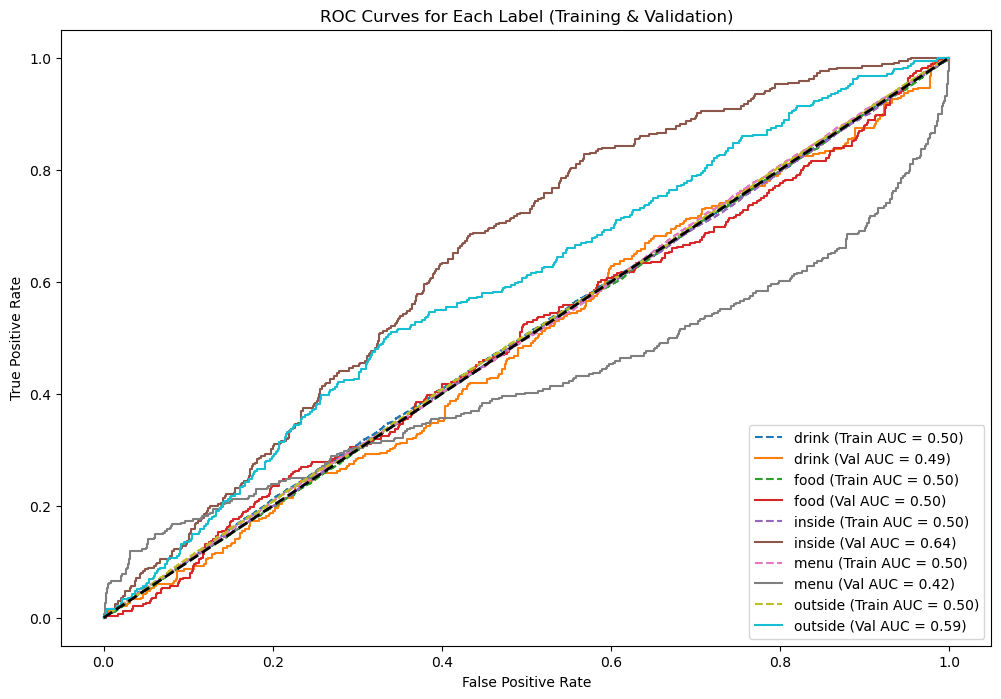

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Set up the figure
plt.figure(figsize=(12, 8))

for i, class_label in enumerate(label_encoder.classes_):
    # Compute ROC curve for training set
    fpr_train, tpr_train, _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc_train = auc(fpr_train, tpr_train)

    # Compute ROC curve for validation set
    fpr_val, tpr_val, _ = roc_curve(y_val_bin[:, i], y_val_prob[:, i])
    roc_auc_val = auc(fpr_val, tpr_val)

    # Plot both training and validation curves
    plt.plot(fpr_train, tpr_train, linestyle="--", label=f"{class_label} (Train AUC = {roc_auc_train:.2f})")
    plt.plot(fpr_val, tpr_val, label=f"{class_label} (Val AUC = {roc_auc_val:.2f})")

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], "k--", lw=2)

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Label (Training & Validation)")
plt.legend(loc="lower right")
plt.show()

## Oh nice, it looks somehow like a Violin :P

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 33ms/step
Top labels explained: [0, 1, 2, 4, 3]


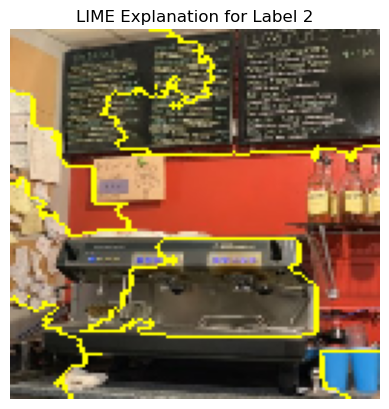

1/1 [==============================] - 0s 429ms/step
Predicted probabilities: [[0.35600114 0.22695948 0.17573978 0.11221772 0.12908186]]
True label probability: 0.17573978006839752


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Ensure the model input format is correct for LIME
def preprocess_image_for_lime(image):
    """Preprocess a single image for LIME (resize, normalize)."""
    image = tf.image.resize(image, (128, 128))  # Resize to match model input
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    return image.numpy()

# Define prediction function for LIME
def predict_proba_for_lime(images):
    """Predict probabilities for a batch of images using the trained DNN."""
    processed_images = np.array([preprocess_image_for_lime(img) for img in images])  # Apply preprocessing
    return model.predict(processed_images)  # Get predictions

# Extract a sample from val_dataset
for batch_images, batch_labels in test_dataset.take(1):
    test_image = batch_images[1].numpy()  # Extract an image
    test_label = batch_labels[1].numpy()  # Extract the corresponding label
    break  # Stop after first batch

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate explanation
explanation = explainer.explain_instance(
    test_image,  
    predict_proba_for_lime,  # Prediction function for LIME
    labels=[test_label],  # Focus on the true label
    hide_color=0,  
    num_samples=1000  # Number of perturbed samples
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Get LIME mask for the true label
temp, mask = explanation.get_image_and_mask(
    label=test_label,  
    positive_only=True,  
    num_features=10,  
    hide_rest=False  
)

# Convert to proper format if needed
if len(temp.shape) == 2:  
    temp = np.stack([temp] * 3, axis=-1)  # Convert grayscale to RGB

# Overlay mask on image
overlay = mark_boundaries(temp, mask)

# Display explanation
plt.imshow(overlay)
plt.title(f"LIME Explanation for Label {test_label}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = predict_proba_for_lime([test_image])
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, test_label]}")


In [69]:
class_names = label_encoder.classes_
print("Class names:", class_names)

Class names: ['drink' 'food' 'inside' 'menu' 'outside']


## Atleast it predicted inside right XD

### Again.
- The model is already too complex. I will try to unfreezer less layers we are doing 3 I will do 1.
- I will increase dropout and add batchnormalization
- Chaning the method of augmentation to specific labels

# Final round of empirical Tuning

In [97]:
# Print label mappings
print("Label Mapping:", label_mapping)

# Find integer values for "food", "inside", "outside"
augment_classes = [label_mapping[label] for label in ["food", "inside", "outside"]]
print("Classes to Augment:", augment_classes)


Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}
Classes to Augment: [1, 2, 4]


In [98]:
def apply_augmentation(image, label, IMAGE_SIZE=(128, 128), augment_classes=[1, 2, 4]):  
    """Apply data augmentation only to specific integer-labeled classes."""
    
    # Convert label to int before checking
    label_is_target = tf.reduce_any(tf.equal(label, augment_classes))

    # Augment function (only applied to target classes)
    def augment_fn():
        augmented_images = []

        # Original image (no augmentation)
        augmented_images.append(image)

        # Augmented versions
        augmented_images.append(tf.image.random_flip_left_right(image))
        augmented_images.append(tf.image.random_flip_up_down(image))
        augmented_images.append(tf.image.random_brightness(image, max_delta=0.3))
        augmented_images.append(tf.image.random_contrast(image, lower=0.7, upper=1.3))
        augmented_images.append(tf.image.rot90(image))  # Rotate 90 degrees

        # Central crop (fix shape mismatch)
        cropped_image = tf.image.central_crop(image, central_fraction=0.8)
        cropped_image = tf.image.resize(cropped_image, IMAGE_SIZE)  # Resize back to 128x128
        augmented_images.append(cropped_image)

        return tf.stack(augmented_images)  # Convert list to Tensor

    # Only apply augmentation if label matches target classes
    augmented_images = tf.cond(label_is_target, augment_fn, lambda: tf.expand_dims(image, axis=0))

    return augmented_images


In [99]:
import tensorflow as tf

def apply_augmentation(image, label, IMAGE_SIZE=(128, 128), augment_classes=[1, 2, 4]):  
    """Apply data augmentation only to specific integer-labeled classes."""
    
    # Convert label to int before checking
    label_is_target = tf.reduce_any(tf.equal(label, augment_classes))

    # Augment function (only applied to target classes)
    def augment_fn():
        augmented_images = []

        # Original image (no augmentation)
        augmented_images.append(image)

        # Augmented versions
        augmented_images.append(tf.image.random_flip_left_right(image))
        augmented_images.append(tf.image.random_flip_up_down(image))
        augmented_images.append(tf.image.random_brightness(image, max_delta=0.3))
        augmented_images.append(tf.image.random_contrast(image, lower=0.7, upper=1.3))
        augmented_images.append(tf.image.rot90(image))  # Rotate 90 degrees

        # Central crop (fix shape mismatch)
        cropped_image = tf.image.central_crop(image, central_fraction=0.8)
        cropped_image = tf.image.resize(cropped_image, IMAGE_SIZE)  # Resize back to 128x128
        augmented_images.append(cropped_image)

        return tf.stack(augmented_images)  # Convert list to Tensor

    # Only apply augmentation if label matches target classes
    augmented_images = tf.cond(label_is_target, augment_fn, lambda: tf.expand_dims(image, axis=0))

    return augmented_images


In [100]:
def load_image_label(image_path, label, IMAGE_SIZE=(128, 128), augment=False, augment_classes=[1, 2, 4]):
    """Load, preprocess, and optionally apply augmentation to an image."""
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)  # Resize for EfficientNetB0
        img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]

        # Ensure label is an integer tensor
        label = tf.convert_to_tensor(label, dtype=tf.int32)

        # Apply augmentation only for target classes
        if augment:
            augmented_imgs = apply_augmentation(img, label, augment_classes=augment_classes)
            labels = tf.repeat(label, tf.shape(augmented_imgs)[0])  # Repeat labels for augmentation
            return tf.data.Dataset.from_tensor_slices((augmented_imgs, labels))  # Flatten dataset
        
        return tf.data.Dataset.from_tensors((img, label))  # Wrap single image in dataset
    except tf.errors.InvalidArgumentError:
        print(f"Skipping corrupt image: {image_path}")
        return tf.data.Dataset.from_tensors((tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label))


In [101]:
# Load images into TensorFlow datasets
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 128
IMG_DIR = "data/photos"

# Load train dataset with augmentation
train_dataset = load_images_with_tf(train_df["photo_id"].values, train_df["label"].values, IMG_DIR, IMAGE_SIZE, BATCH_SIZE,augment=True)
test_dataset = load_images_without_augmentation(test_df["photo_id"].values, test_df["label"].values, IMG_DIR, IMAGE_SIZE, BATCH_SIZE)

In [102]:
def load_b0_and_create_model():
    # Load EfficientNetB0 with custom input size
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = True  # Enable fine-tuning

    # Unfreeze the last layer
    for layer in base_model.layers[-1:]:
        layer.trainable = True

    model = tf.keras.Sequential([
        base_model,  
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),  # Conv layer after base model
        layers.Dropout(0.6),  # Normalize activations
        layers.MaxPooling2D(pool_size=(2, 2)),  # Reduce spatial size
        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),  # Another Conv layer
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),  # Pooling again
        
        layers.GlobalAveragePooling2D(),  # Convert to 1D before Dense layer
        layers.Dropout(0.5),  # Increased dropout to prevent overfitting
        layers.Dense(5, activation="softmax")  # Final classification layer
    ])

    return model

In [103]:
model = load_b0_and_create_model()

In [104]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [105]:
import time

# Start timing
start_time = time.time()
model.fit(train_dataset, epochs=5, validation_data=test_dataset)
# End timing
end_time = time.time()

# Print total training time
total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")

Epoch 1/5
241/241 [==============================] - 55s 162ms/step - loss: 0.3760 - accuracy: 0.8796 - val_loss: 2.5017 - val_accuracy: 0.2002
Epoch 2/5
241/241 [==============================] - 53s 184ms/step - loss: 0.1198 - accuracy: 0.9613 - val_loss: 1.9039 - val_accuracy: 0.2044
Epoch 3/5
241/241 [==============================] - 57s 196ms/step - loss: 0.0699 - accuracy: 0.9778 - val_loss: 2.6279 - val_accuracy: 0.2205
Epoch 4/5
241/241 [==============================] - 62s 219ms/step - loss: 0.0600 - accuracy: 0.9801 - val_loss: 1.7972 - val_accuracy: 0.2300
Epoch 5/5
241/241 [==============================] - 63s 221ms/step - loss: 0.0509 - accuracy: 0.9830 - val_loss: 2.2573 - val_accuracy: 0.2002
Total training time: 309.98 seconds


- Epoch 1/3
- 367/367 [==============================] - 79s 176ms/step - loss: 0.4904 - accuracy: 0.8514 - val_loss: 1.6783 - val_accuracy: 0.2533
- Epoch 2/3
- 367/367 [==============================] - 89s 226ms/step - loss: 0.2347 - accuracy: 0.9304 - val_loss: 1.8164 - val_accuracy: 0.2485
- Epoch 3/3
- 367/367 [==============================] - 91s 226ms/step - loss: 0.1671 - accuracy: 0.9524 - val_loss: 1.8165 - val_accuracy: 0.2002
- Total training time: 258.52 seconds

In [106]:
model.save_weights("efficientnetb0_tune2_weights.h5")

# Train

In [107]:
# Extract true labels from the dataset (instead of `train_df`)
y_true = np.concatenate([y.numpy() for _, y in train_dataset])

# Get model predictions
y_pred_prob = model.predict(train_dataset)

# Compute AUC
overall_auc = roc_auc_score(y_true, y_pred_prob, multi_class="ovr")
print(f"Overall AUC: {overall_auc:.4f}")

241/241 [==============================] - 30s 86ms/step
Overall AUC: 0.5039


In [108]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
num_classes = len(label_encoder.classes_)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute AUC per class
auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
for i, class_label in enumerate(label_encoder.classes_):
    print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

AUC for drink: 0.5196
AUC for food: 0.4972
AUC for inside: 0.5023
AUC for menu: 0.5012
AUC for outside: 0.4994


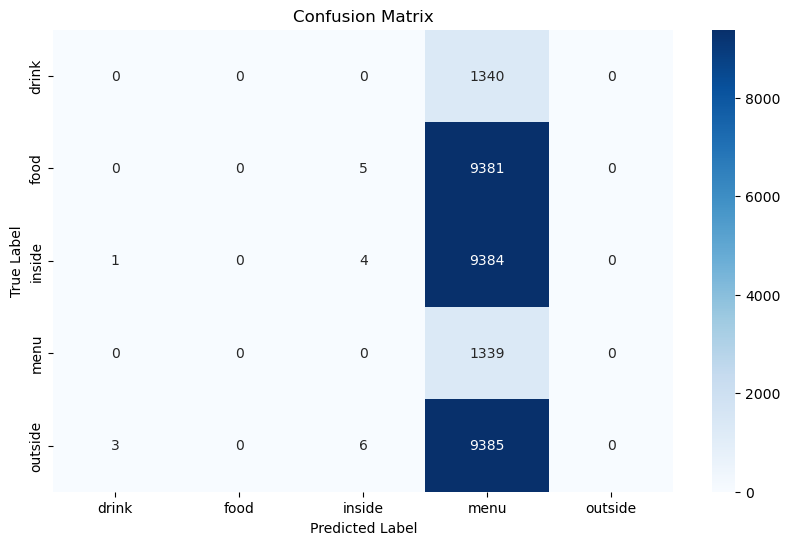

In [109]:
# Convert predictions to class labels
y_pred_classes = y_pred_prob.argmax(axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Ha, now Menu is the powerful one :S

# Test

In [110]:
# Get model predictions
y_pred_prob = model.predict(test_dataset)  # Predicted probabilities
y_true = test_df["label"].values  # True labels

# Compute AUC
overall_auc = roc_auc_score(y_true, y_pred_prob, multi_class="ovr")
print(f"Overall AUC: {overall_auc:.4f}")

14/14 [==============================] - 2s 78ms/step
Overall AUC: 0.5400


In [111]:
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot encoding
num_classes = len(label_encoder.classes_)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute AUC per class
auc_per_class = roc_auc_score(y_true_bin, y_pred_prob, average=None)
for i, class_label in enumerate(label_encoder.classes_):
    print(f"AUC for {class_label}: {auc_per_class[i]:.4f}")

AUC for drink: 0.5924
AUC for food: 0.4947
AUC for inside: 0.5088
AUC for menu: 0.5815
AUC for outside: 0.5226


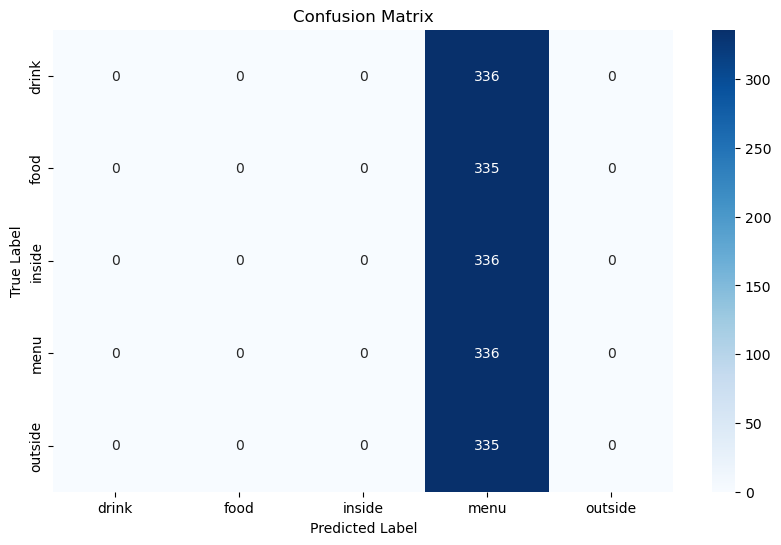

In [112]:
# Convert predictions to class labels
y_pred_classes = y_pred_prob.argmax(axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ROC AUC Curve

In [113]:
from sklearn.preprocessing import label_binarize

# Get model predictions (probabilities)
y_train_prob = model.predict(train_dataset)
y_val_prob = model.predict(test_dataset)

14/14 [==============================] - 1s 63ms/step


In [114]:
# Convert true labels to NumPy arrays
y_train_true = y_true = np.concatenate([y.numpy() for _, y in train_dataset])
y_val_true = test_df["label"].values

# Convert labels to one-hot encoding for ROC curve
num_classes = len(label_encoder.classes_)
y_train_bin = label_binarize(y_train_true, classes=list(range(num_classes)))
y_val_bin = label_binarize(y_val_true, classes=list(range(num_classes)))

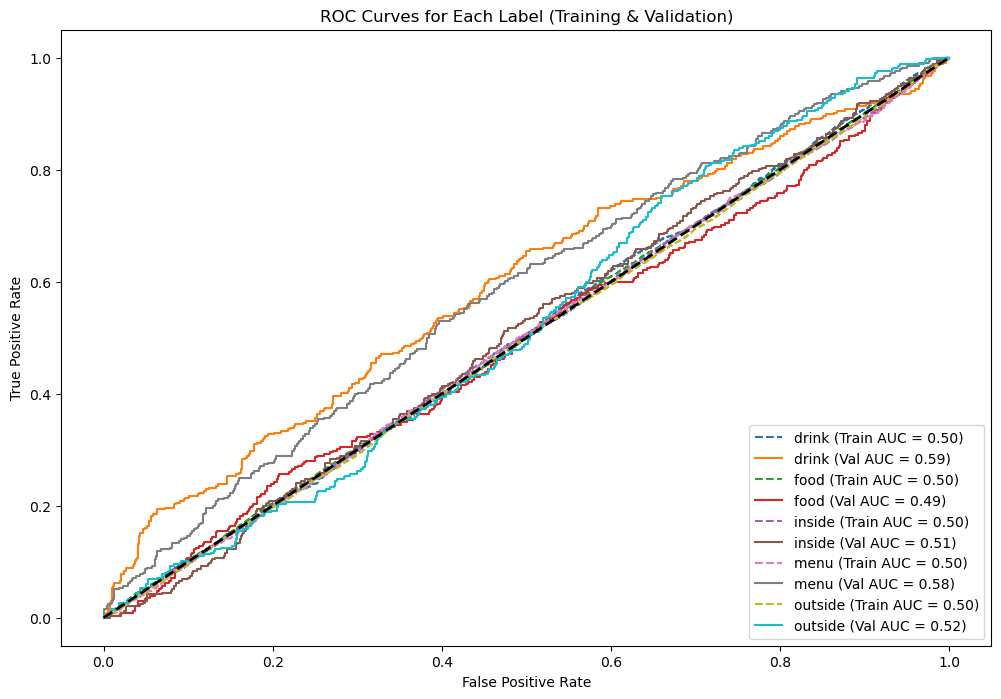

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Set up the figure
plt.figure(figsize=(12, 8))

for i, class_label in enumerate(label_encoder.classes_):
    # Compute ROC curve for training set
    fpr_train, tpr_train, _ = roc_curve(y_train_bin[:, i], y_train_prob[:, i])
    roc_auc_train = auc(fpr_train, tpr_train)

    # Compute ROC curve for validation set
    fpr_val, tpr_val, _ = roc_curve(y_val_bin[:, i], y_val_prob[:, i])
    roc_auc_val = auc(fpr_val, tpr_val)

    # Plot both training and validation curves
    plt.plot(fpr_train, tpr_train, linestyle="--", label=f"{class_label} (Train AUC = {roc_auc_train:.2f})")
    plt.plot(fpr_val, tpr_val, label=f"{class_label} (Val AUC = {roc_auc_val:.2f})")

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], "k--", lw=2)

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Each Label (Training & Validation)")
plt.legend(loc="lower right")
plt.show()

## atleast only a few of them are below a coin now

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 34ms/step
Top labels explained: [3, 0, 2, 1, 4]


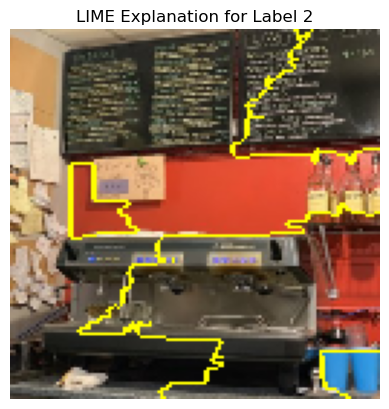

1/1 [==============================] - 0s 32ms/step
Predicted probabilities: [[0.16962697 0.03839986 0.10011231 0.671836   0.02002485]]
True label probability: 0.10011231154203415


In [116]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Ensure the model input format is correct for LIME
def preprocess_image_for_lime(image):
    """Preprocess a single image for LIME (resize, normalize)."""
    image = tf.image.resize(image, (128, 128))  # Resize to match model input
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    return image.numpy()

# Define prediction function for LIME
def predict_proba_for_lime(images):
    """Predict probabilities for a batch of images using the trained DNN."""
    processed_images = np.array([preprocess_image_for_lime(img) for img in images])  # Apply preprocessing
    return model.predict(processed_images)  # Get predictions

# Extract a sample from val_dataset
for batch_images, batch_labels in test_dataset.take(1):
    test_image = batch_images[1].numpy()  # Extract an image
    test_label = batch_labels[1].numpy()  # Extract the corresponding label
    break  # Stop after first batch

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Generate explanation
explanation = explainer.explain_instance(
    test_image,  
    predict_proba_for_lime,  # Prediction function for LIME
    labels=[test_label],  # Focus on the true label
    hide_color=0,  
    num_samples=1000  # Number of perturbed samples
)

# Check the top labels explained
print("Top labels explained:", explanation.top_labels)

# Get LIME mask for the true label
temp, mask = explanation.get_image_and_mask(
    label=test_label,  
    positive_only=True,  
    num_features=10,  
    hide_rest=False  
)

# Convert to proper format if needed
if len(temp.shape) == 2:  
    temp = np.stack([temp] * 3, axis=-1)  # Convert grayscale to RGB

# Overlay mask on image
overlay = mark_boundaries(temp, mask)

# Display explanation
plt.imshow(overlay)
plt.title(f"LIME Explanation for Label {test_label}")
plt.axis("off")
plt.show()

# Debugging: Check predicted probabilities
proba = predict_proba_for_lime([test_image])
print(f"Predicted probabilities: {proba}")
print(f"True label probability: {proba[0, test_label]}")


In [117]:
class_names = label_encoder.classes_
print("Class names:", class_names)

Class names: ['drink' 'food' 'inside' 'menu' 'outside']
